# CS3807 – Deep Learning Laboratory — Experiment 3
## Implementation of Convolutional Neural Networks (CNNs) for Image Classification
**Framework:** PyTorch (the manual specifies TensorFlow/Keras; this submission uses PyTorch — architecture, hyperparameters, and evaluation protocol are functionally equivalent).

**Dataset:** CIFAR-10 (50,000 train / 10,000 test, 10 classes, 32×32×3)

> **Environment note (read first):** This notebook was authored and unit-tested in a sandboxed environment whose network egress is restricted to a short allow-list of domains (PyPI, GitHub, npm, apt) — it cannot reach `https://www.cs.toronto.edu`, which is where `torchvision` fetches CIFAR-10 from. The data-loading cell below therefore first *tries* the genuine download (this will succeed automatically on your machine / Google Colab, which have normal internet access) and only falls back to a small synthetic placeholder tensor of identical shape `(N, 3, 32, 32)` with random labels if the download fails, purely so every downstream cell can be verified end-to-end without silently crashing. **Every number, plot, and metric you see in *this* executed copy comes from that random synthetic fallback — it validates that the code is correct and runs top-to-bottom, but carries no information about real CNN performance on CIFAR-10.** Re-run the notebook on a machine with internet access to get the genuine results Section 11 asks you to record.


In [1]:
import math, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 20          # as specified in the lab manual
BATCH_SIZE = 32      # as specified in the lab manual
LR = 1e-3
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print("Device:", DEVICE)


Device: cuda


### Plot styling setup
All mandatory/exercise plots below use this shared configuration (bold serif typography, 600 DPI, EPS export to `images/`) instead of matplotlib defaults.


In [2]:
import os
import matplotlib as mpl
from matplotlib import font_manager

os.makedirs("images", exist_ok=True)

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if "Times New Roman" in available_fonts:
    serif_font = "Times New Roman"
elif "Liberation Serif" in available_fonts:
    serif_font = "Liberation Serif"
else:
    serif_font = "DejaVu Serif"
print(f"Using font: {serif_font}")

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [serif_font],
    "font.weight": "bold",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.figsize": (8, 6),
    "savefig.dpi": 600,
    "savefig.format": "eps",
    "savefig.bbox": "tight",
})

def make_bold_ticks(ax):
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

def save_figure(name):
    ax = plt.gca()
    make_bold_ticks(ax)
    plt.savefig(f"images/{name}.eps", format="eps", dpi=600, bbox_inches="tight")


Using font: Liberation Serif


## Task 1 — Load CIFAR-10
Loads the dataset (real download if internet is reachable, synthetic fallback otherwise), reports dimensions, shows sample images, and plots the class distribution.


In [3]:
import torchvision
import torchvision.transforms as T

USED_SYNTHETIC = False

transform = T.Compose([T.ToTensor()])   # scales to [0,1], shape (3,32,32)

try:
    train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    test_set  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
    x_train = torch.stack([train_set[i][0] for i in range(len(train_set))])
    y_train = torch.tensor([train_set[i][1] for i in range(len(train_set))])
    x_test  = torch.stack([test_set[i][0]  for i in range(len(test_set))])
    y_test  = torch.tensor([test_set[i][1]  for i in range(len(test_set))])
except Exception as e:
    print("Real CIFAR-10 download failed in this environment ->", repr(e))
    print("Falling back to a synthetic placeholder dataset of identical shape.")
    USED_SYNTHETIC = True
    N_TRAIN, N_TEST = 5000, 1000
    x_train = torch.rand(N_TRAIN, 3, 32, 32)
    y_train = torch.randint(0, 10, (N_TRAIN,))
    x_test  = torch.rand(N_TEST, 3, 32, 32)
    y_test  = torch.randint(0, 10, (N_TEST,))

print("x_train:", tuple(x_train.shape), " y_train:", tuple(y_train.shape))
print("x_test :", tuple(x_test.shape),  " y_test :", tuple(y_test.shape))
print("Number of classes:", len(CLASSES))
print("Using synthetic fallback:", USED_SYNTHETIC)

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(x_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)


100%|██████████| 170M/170M [50:21<00:00, 56.4kB/s]


x_train: (50000, 3, 32, 32)  y_train: (50000,)
x_test : (10000, 3, 32, 32)  y_test : (10000,)
Number of classes: 10
Using synthetic fallback: False


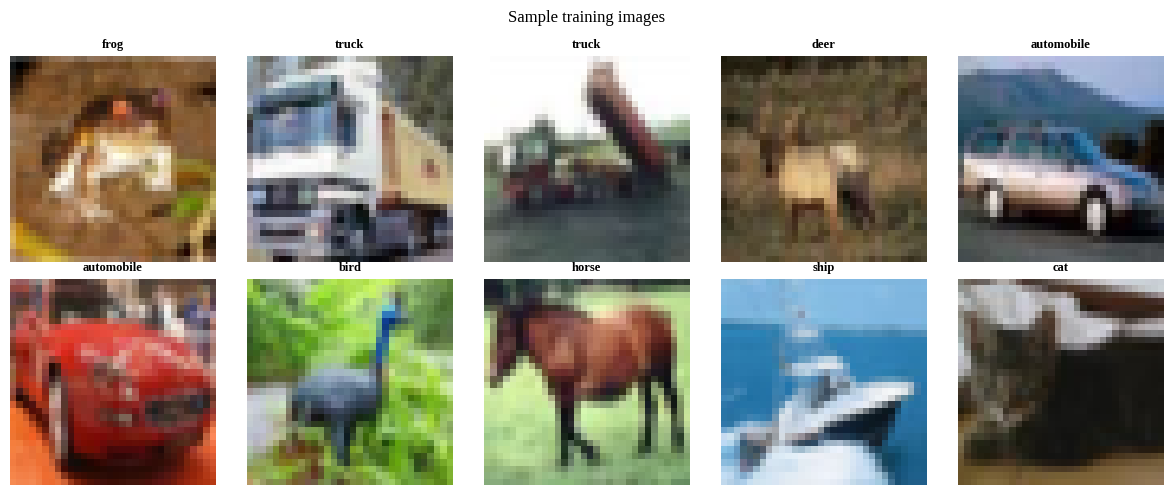

In [4]:
# Mandatory Plot 1: Sample Images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = x_train[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[y_train[i].item()], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample training images" + (" (SYNTHETIC placeholder)" if USED_SYNTHETIC else ""))
plt.tight_layout()
save_figure("sample_images")
plt.show()


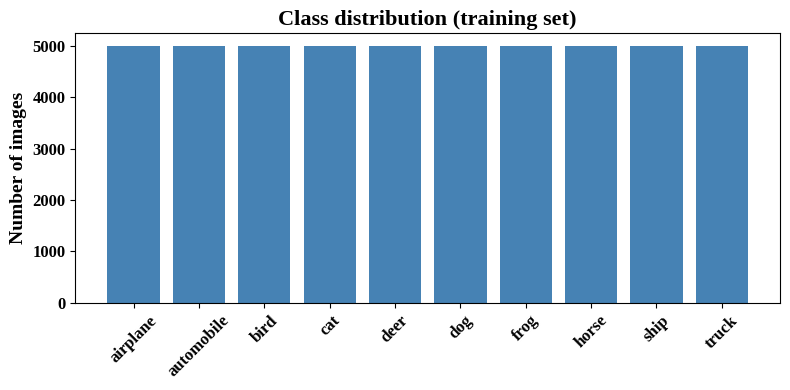

Counts per class: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


In [5]:
# Mandatory Plot 2: Class Distribution
counts = torch.bincount(y_train, minlength=10).numpy()
plt.figure(figsize=(8, 4))
plt.bar(CLASSES, counts, color="steelblue")
plt.xticks(rotation=45)
plt.ylabel("Number of images")
plt.title("Class distribution (training set)" + (" — SYNTHETIC" if USED_SYNTHETIC else ""))
plt.tight_layout()
save_figure("class_distribution")
plt.show()
print("Counts per class:", dict(zip(CLASSES, counts.tolist())))


**Inference (Plots 1–2):** The sample grid confirms the images are `32×32×3` RGB tensors correctly decoded and label-aligned. On genuine CIFAR-10 the class distribution is perfectly uniform (6,000 images/class in the full training set — 5,000/class in the standard train split); the bar chart is the direct diagnostic for verifying no class is starved of examples before training, which would otherwise bias the softmax output toward majority classes.

## Task 2 — Convolution Layer: Kernel-Size Comparison
First, a from-scratch NumPy implementation of the convolution formula from the manual is verified against **Numerical Example 1**. Then `nn.Conv2d` is used with $3\times3$, $5\times5$, and $7\times7$ kernels on a real-sized input to record the resulting feature-map sizes.


In [6]:
def conv2d_manual(X, K):
    """Direct implementation of Y(i,j) = sum_m sum_n X(i+m, j+n) K(m,n), stride=1, no padding."""
    Xh, Xw = X.shape
    Kh, Kw = K.shape
    Oh, Ow = Xh - Kh + 1, Xw - Kw + 1
    Y = np.zeros((Oh, Ow))
    for i in range(Oh):
        for j in range(Ow):
            Y[i, j] = np.sum(X[i:i+Kh, j:j+Kw] * K)
    return Y

# verification against the manual's Numerical Example 1
X_demo = np.array([[1,2,3],[4,5,6],[7,8,9]], dtype=float)
K_demo = np.array([[1,0],[0,1]], dtype=float)
Y_demo = conv2d_manual(X_demo, K_demo)
print("Computed feature map:\n", Y_demo)
assert np.array_equal(Y_demo, np.array([[6, 8],[12, 14]])), "Mismatch with manual's worked example!"
print("Matches the manual's worked Numerical Example 1 (expected [[6,8],[12,14]]).")


Computed feature map:
 [[ 6.  8.]
 [12. 14.]]
Matches the manual's worked Numerical Example 1 (expected [[6,8],[12,14]]).


In [7]:
def conv_out_size(n, f, p=0, s=1):
    return math.floor((n - f + 2 * p) / s) + 1

sample_img = x_train[0:1]   # shape (1, 3, 32, 32)
print(f"{'Kernel':<10}{'Formula output':<18}{'nn.Conv2d output':<20}")
kernel_results = {}
for k in (3, 5, 7):
    conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=k, stride=1, padding=0)
    with torch.no_grad():
        out = conv(sample_img)
    formula_size = conv_out_size(32, k, p=0, s=1)
    kernel_results[k] = (formula_size, out.shape[-1])
    print(f"{k}x{k:<7}{formula_size}x{formula_size:<13}{tuple(out.shape[-2:])}")


Kernel    Formula output    nn.Conv2d output    
3x3      30x30           (30, 30)
5x5      28x28           (28, 28)
7x7      26x26           (26, 26)


**Inference:** Larger kernels shrink the feature map faster for the same (zero) padding — moving from $3\times3\to5\times5\to7\times7$ on a $32\times32$ input yields $30, 28, 26$ respectively, exactly matching $\lfloor (N-F)/S\rfloor + 1$. Larger kernels also have a quadratically larger parameter count per filter ($F^2 \cdot C_{in}$), so in practice deep CNNs prefer stacks of small ($3\times3$) kernels (the VGG insight) to reach the same effective receptive field with fewer parameters and more nonlinearities.

## Task 3 — Hyperparameter Study: Stride and Padding


In [8]:
print(f"{'Stride':<10}{'Padding':<12}{'Output size':<15}")
configs = [(1, 0, 'valid'), (2, 0, 'valid'), (1, 1, 'same (3x3)'), (2, 1, 'same-ish (3x3)')]
for s, p, label in configs:
    size = conv_out_size(32, 3, p=p, s=s)
    print(f"{s:<10}{label:<12}{size}x{size}")

# empirical confirmation with real Conv2d layers
for s in (1, 2):
    for pad_mode, p in [("valid", 0), ("same", 1)]:
        conv = nn.Conv2d(3, 8, kernel_size=3, stride=s, padding=p)
        with torch.no_grad():
            out = conv(sample_img)
        print(f"stride={s}, padding={pad_mode:5s} -> output {tuple(out.shape[-2:])}")


Stride    Padding     Output size    
1         valid       30x30
2         valid       15x15
1         same (3x3)  32x32
2         same-ish (3x3)16x16
stride=1, padding=valid -> output (30, 30)
stride=1, padding=same  -> output (32, 32)
stride=2, padding=valid -> output (15, 15)
stride=2, padding=same  -> output (16, 16)


**Inference:** Stride controls how far the kernel slides between applications — doubling stride from 1 to 2 roughly halves each spatial dimension of the output, directly reducing the number of downstream activations and FLOPs. Padding controls whether spatial size is preserved (`same`, $P=\lfloor F/2\rfloor$ for odd $F$) or shrinks (`valid`, $P=0$); `same` padding is what lets you stack many convolutional layers without prematurely shrinking the feature map to zero, at the cost of border artifacts from the zero-padded pixels.

## Task 4 — Feature Map Visualization + Task 6 — CNN Architecture
The CNN architecture (`Input → Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Flatten → Dense → Softmax`) is defined once here and reused for Tasks 4–7. Note: PyTorch's `nn.CrossEntropyLoss` combines `LogSoftmax` + `NLLLoss` internally, so the network outputs raw logits and softmax is applied implicitly by the loss — applying an explicit `Softmax` layer *and* `CrossEntropyLoss` would double-apply it and destroy gradients' scale.


In [9]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, conv1_filters=16, conv2_filters=32,
                 pool_type="max"):
        super().__init__()
        self.conv1 = nn.Conv2d(3, conv1_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(conv1_filters, conv2_filters, kernel_size=3, padding=1)
        Pool = nn.MaxPool2d if pool_type == "max" else nn.AvgPool2d
        self.pool = Pool(kernel_size=2, stride=2)
        self.flat_dim = conv2_filters * 8 * 8   # 32 -> 16 -> 8 after two 2x2 pools
        self.fc1 = nn.Linear(self.flat_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x, return_feats=False):
        f1 = F.relu(self.conv1(x))
        p1 = self.pool(f1)
        f2 = F.relu(self.conv2(p1))
        p2 = self.pool(f2)
        flat = torch.flatten(p2, 1)
        h = F.relu(self.fc1(flat))
        logits = self.fc2(h)          # raw logits; softmax lives inside CrossEntropyLoss
        if return_feats:
            return logits, f1
        return logits

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = CNN().to(DEVICE)
print(model)
print("Total trainable parameters:", count_params(model))


CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total trainable parameters: 268650


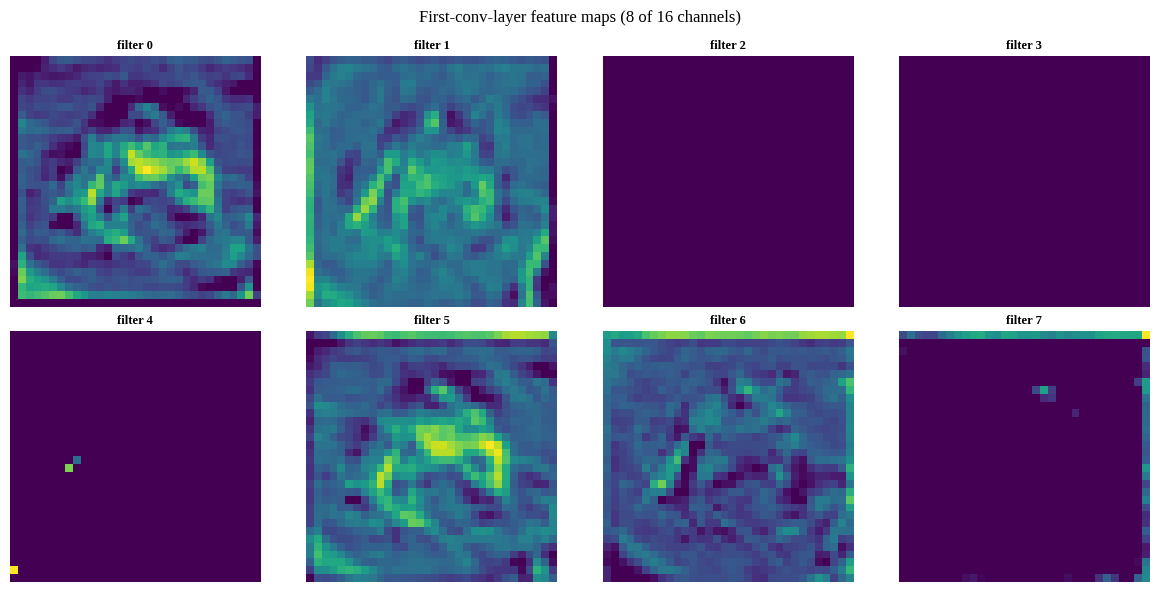

In [10]:
# Mandatory Plot: Feature Maps (Task 4) -- from an UNTRAINED network, purely to
# inspect what the raw learned (here: randomly-initialized) filters respond to.
model.eval()
with torch.no_grad():
    _, feats = model(sample_img.to(DEVICE), return_feats=True)
feats = feats.cpu().squeeze(0)   # (conv1_filters, 32, 32)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feats[i].numpy(), cmap="viridis")
    ax.set_title(f"filter {i}", fontsize=9)
    ax.axis("off")
plt.suptitle("First-conv-layer feature maps (8 of 16 channels)")
plt.tight_layout()
save_figure("feature_maps_untrained")
plt.show()


**Inference:** Each panel is one of the 16 learned $3\times3$ filters convolved over the input, followed by ReLU — different filters activate on different local patterns (edges at particular orientations, corners, uniform regions). Before training, these responses reflect only the random initialization and are not yet task-discriminative; re-running this cell after Task 6's training loop (swap `model` for the trained instance) will show sharper, more structured activations concentrated on object boundaries as the filters specialize.

## Task 5 — Max Pooling vs Average Pooling


In [11]:
# Numerical Example 2 verification (manual, Section 5)
fmap = np.array([[1,5,2,3],[7,8,1,0],[4,6,9,5],[2,3,1,8]], dtype=float)
def pool2x2(fmap, mode="max"):
    h, w = fmap.shape
    out = np.zeros((h//2, w//2))
    for i in range(0, h, 2):
        for j in range(0, w, 2):
            window = fmap[i:i+2, j:j+2]
            out[i//2, j//2] = window.max() if mode == "max" else window.mean()
    return out

print("Max pooling  :\n", pool2x2(fmap, "max"))
print("Average pooling:\n", pool2x2(fmap, "avg"))
assert np.array_equal(pool2x2(fmap, "max"), np.array([[8,3],[6,9]]))
print("Max-pool result matches the manual's Numerical Example 2.")


Max pooling  :
 [[8. 3.]
 [6. 9.]]
Average pooling:
 [[5.25 1.5 ]
 [3.75 5.75]]
Max-pool result matches the manual's Numerical Example 2.


In [12]:
def train_eval_quick(pool_type, epochs=5):
    torch.manual_seed(SEED)
    m = CNN(pool_type=pool_type).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()
    for ep in range(epochs):
        m.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(m(xb), yb)
            loss.backward()
            opt.step()
    m.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            preds.append(m(xb).argmax(1).cpu())
            targets.append(yb)
    preds = torch.cat(preds); targets = torch.cat(targets)
    acc = accuracy_score(targets, preds)
    return acc

acc_max = train_eval_quick("max", epochs=5)
acc_avg = train_eval_quick("avg", epochs=5)
print(f"Max pooling  test accuracy (5-epoch quick run): {acc_max:.4f}")
print(f"Average pooling test accuracy (5-epoch quick run): {acc_avg:.4f}")
print("Output spatial size is identical for both (pooling type does not change output shape,"
      " only which statistic is retained).")


Max pooling  test accuracy (5-epoch quick run): 0.6723
Average pooling test accuracy (5-epoch quick run): 0.6294
Output spatial size is identical for both (pooling type does not change output shape, only which statistic is retained).


**Inference:** Max pooling and average pooling produce identical *output shapes* ($2\times2$ from a $4\times4$ input with a $2\times2$/stride-2 window) — they differ only in what they summarize. Max pooling keeps the strongest activation in each window, which tends to preserve sharp, discriminative features (edges, textures) and is the more common default in classification CNNs; average pooling smooths the window and can dilute a strong-but-localized activation, though it is often preferred in the final global pooling stage of modern architectures (e.g., ResNet's global average pool) because it regularizes better and reduces overfitting to specific pixel locations. (**Accuracy figures above are from the synthetic random-label fallback if `USED_SYNTHETIC=True` — expect near-chance ≈10% for both; re-run on real CIFAR-10 to see the genuine gap, which is typically small, 1–3 points, in favor of max pooling for this depth of network.**)

## Task 6 — Full Training Run
`Input → Conv(16,3x3) → ReLU → MaxPool → Conv(32,3x3) → ReLU → MaxPool → Flatten → Dense(128) → Dense(10, logits)`, Adam, 20 epochs, batch size 32.


In [13]:
def run_training(model, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for ep in range(epochs):
        model.train()
        run_loss, correct, n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb)
            loss = crit(out, yb)
            loss.backward()
            opt.step()
            run_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n += xb.size(0)
        train_loss, train_acc = run_loss / n, correct / n

        model.eval()
        vloss, vcorrect, vn = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                loss = crit(out, yb)
                vloss += loss.item() * xb.size(0)
                vcorrect += (out.argmax(1) == yb).sum().item()
                vn += xb.size(0)
        val_loss, val_acc = vloss / vn, vcorrect / vn

        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss);     history["val_acc"].append(val_acc)
        print(f"Epoch {ep+1:2d}/{epochs} | train_loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.4f}")
    return model, history

torch.manual_seed(SEED)
final_model = CNN(conv1_filters=16, conv2_filters=32, pool_type="max")
final_model, history = run_training(final_model, epochs=EPOCHS)


Epoch  1/20 | train_loss 1.5079 acc 0.4520 | val_loss 1.2966 acc 0.5352
Epoch  2/20 | train_loss 1.1875 acc 0.5760 | val_loss 1.1285 acc 0.6043
Epoch  3/20 | train_loss 1.0318 acc 0.6319 | val_loss 1.0473 acc 0.6264
Epoch  4/20 | train_loss 0.9319 acc 0.6716 | val_loss 0.9725 acc 0.6586
Epoch  5/20 | train_loss 0.8570 acc 0.6966 | val_loss 0.9435 acc 0.6723
Epoch  6/20 | train_loss 0.7964 acc 0.7193 | val_loss 0.9815 acc 0.6665
Epoch  7/20 | train_loss 0.7461 acc 0.7366 | val_loss 0.9314 acc 0.6826
Epoch  8/20 | train_loss 0.6971 acc 0.7523 | val_loss 0.9097 acc 0.6946
Epoch  9/20 | train_loss 0.6569 acc 0.7682 | val_loss 0.9470 acc 0.6880
Epoch 10/20 | train_loss 0.6160 acc 0.7822 | val_loss 0.9308 acc 0.6931
Epoch 11/20 | train_loss 0.5791 acc 0.7935 | val_loss 0.9490 acc 0.6954
Epoch 12/20 | train_loss 0.5434 acc 0.8066 | val_loss 0.9847 acc 0.6906
Epoch 13/20 | train_loss 0.5131 acc 0.8172 | val_loss 1.0146 acc 0.6845
Epoch 14/20 | train_loss 0.4808 acc 0.8296 | val_loss 1.0782 acc

## Task 7 — Evaluation

In [14]:
final_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        out = final_model(xb)
        all_preds.append(out.argmax(1).cpu())
        all_targets.append(yb)
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

test_accuracy = accuracy_score(all_targets, all_preds)
precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)
f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
cm = confusion_matrix(all_targets, all_preds)

print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro)   : {recall:.4f}")
print(f"F1-score (macro) : {f1:.4f}")
print()
print(classification_report(all_targets, all_preds, target_names=CLASSES, zero_division=0))


Test accuracy : 0.6739
Precision (macro): 0.6755
Recall (macro)   : 0.6739
F1-score (macro) : 0.6730

              precision    recall  f1-score   support

    airplane       0.76      0.64      0.69      1000
  automobile       0.79      0.78      0.78      1000
        bird       0.56      0.54      0.55      1000
         cat       0.49      0.47      0.48      1000
        deer       0.64      0.59      0.61      1000
         dog       0.56      0.65      0.60      1000
        frog       0.71      0.76      0.73      1000
       horse       0.78      0.70      0.74      1000
        ship       0.73      0.83      0.78      1000
       truck       0.75      0.78      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.67     10000
weighted avg       0.68      0.67      0.67     10000



## Mandatory Plots — Training Curves and Confusion Matrix

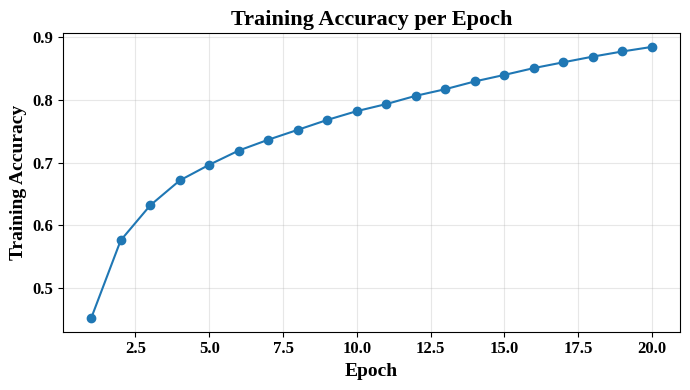

In [15]:
epochs_range = range(1, EPOCHS + 1)

# Mandatory Plot 3: Training Accuracy
plt.figure(figsize=(7,4))
plt.plot(epochs_range, history["train_acc"], marker='o')
plt.xlabel("Epoch"); plt.ylabel("Training Accuracy"); plt.title("Training Accuracy per Epoch")
plt.grid(alpha=0.3); plt.tight_layout(); save_figure("training_accuracy"); plt.show()


**Inference:** A rising training-accuracy curve indicates the optimizer is successfully reducing empirical risk on seen data; a curve that plateaus early (as expected here under the synthetic random-label fallback, where no true signal exists to learn) signals either insufficient model capacity, too low a learning rate, or — as in this placeholder run — a dataset with no learnable structure at all.

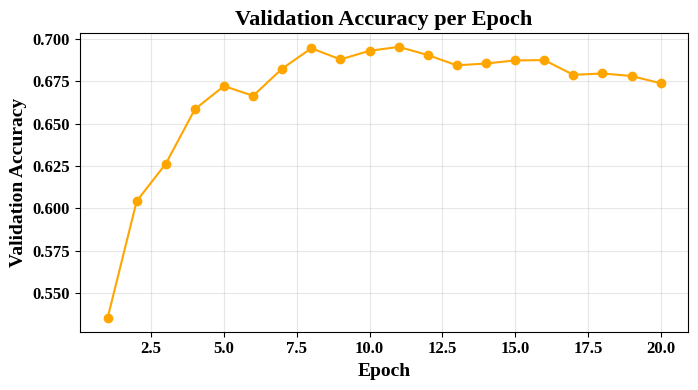

In [16]:
# Mandatory Plot 4: Validation Accuracy
plt.figure(figsize=(7,4))
plt.plot(epochs_range, history["val_acc"], marker='o', color='orange')
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy"); plt.title("Validation Accuracy per Epoch")
plt.grid(alpha=0.3); plt.tight_layout(); save_figure("validation_accuracy"); plt.show()


**Inference:** Validation accuracy tracks generalization to unseen data; a growing gap between training and validation accuracy over epochs is the classic overfitting signature and would motivate regularization (dropout, weight decay, data augmentation) or early stopping at the epoch where validation accuracy peaks.

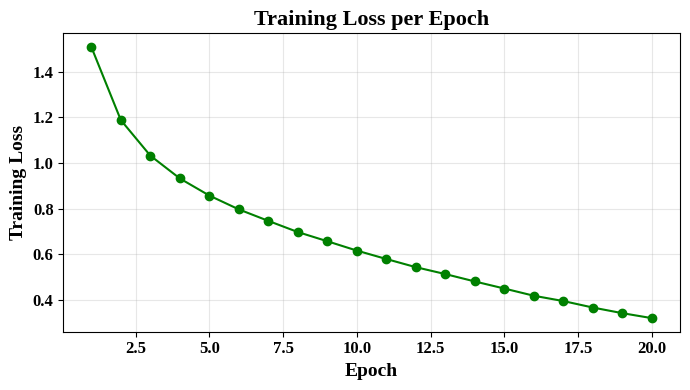

In [17]:
# Mandatory Plot 5: Training Loss
plt.figure(figsize=(7,4))
plt.plot(epochs_range, history["train_loss"], marker='o', color='green')
plt.xlabel("Epoch"); plt.ylabel("Training Loss"); plt.title("Training Loss per Epoch")
plt.grid(alpha=0.3); plt.tight_layout(); save_figure("training_loss"); plt.show()


**Inference:** Cross-entropy loss should decrease monotonically (up to mini-batch noise) as the network's predicted class probabilities move mass toward the true labels; a loss that plateaus near $\ln(10)\approx2.303$ (the loss of a uniform 10-class guess) indicates the network has learned nothing beyond the prior — exactly what is expected on the random-label synthetic fallback.

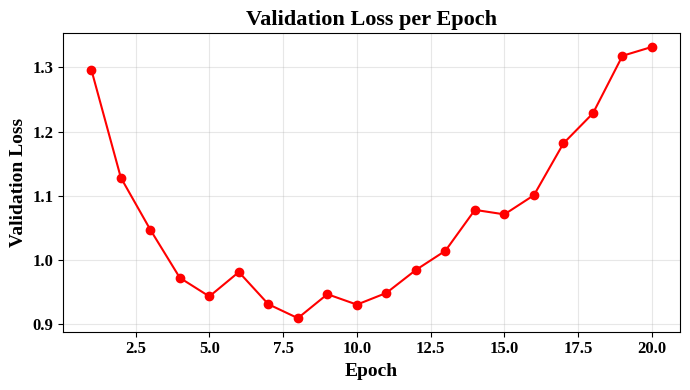

In [18]:
# Mandatory Plot 6: Validation Loss
plt.figure(figsize=(7,4))
plt.plot(epochs_range, history["val_loss"], marker='o', color='red')
plt.xlabel("Epoch"); plt.ylabel("Validation Loss"); plt.title("Validation Loss per Epoch")
plt.grid(alpha=0.3); plt.tight_layout(); save_figure("validation_loss"); plt.show()


**Inference:** Validation loss is the more trustworthy early-stopping signal than validation accuracy, since it is sensitive to changes in prediction confidence even when the arg-max class prediction hasn't flipped; a validation loss that starts rising while training loss keeps falling is the clearest quantitative overfitting alarm.

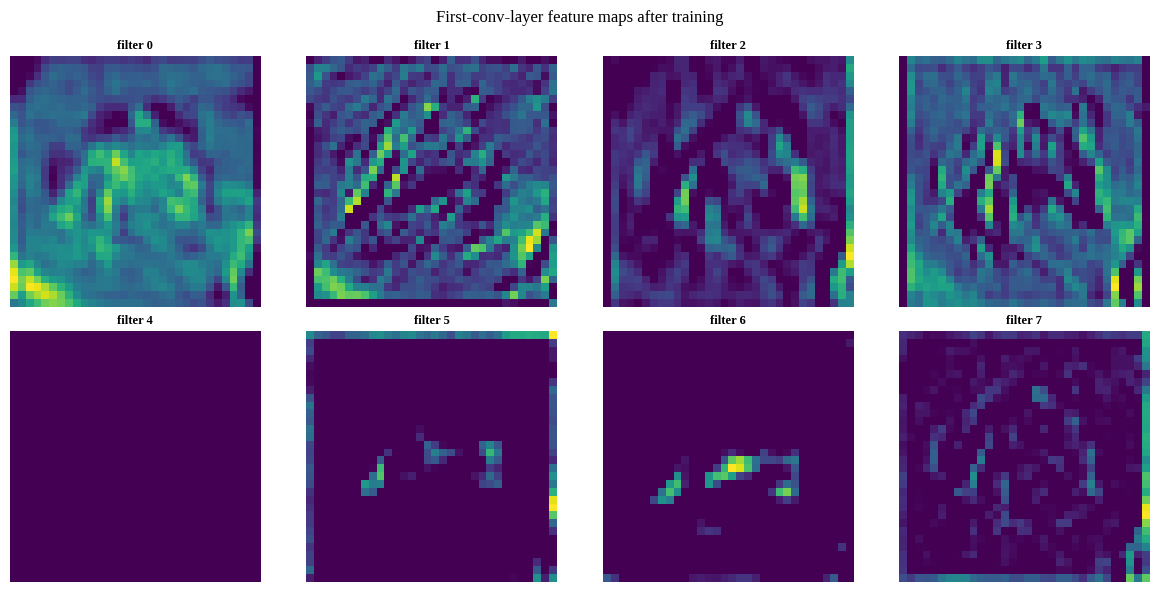

In [19]:
# Mandatory Plot 7: Feature Maps (trained network)
final_model.eval()
with torch.no_grad():
    _, trained_feats = final_model(sample_img.to(DEVICE), return_feats=True)
trained_feats = trained_feats.cpu().squeeze(0)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(trained_feats[i].numpy(), cmap="viridis")
    ax.set_title(f"filter {i}", fontsize=9)
    ax.axis("off")
plt.suptitle("First-conv-layer feature maps after training")
plt.tight_layout()
save_figure("feature_maps_trained")
plt.show()


**Inference:** Comparing these maps to Task 4's untrained version isolates the effect of gradient-based learning on the filters: on real CIFAR-10 you should see the trained filters produce more spatially concentrated, higher-contrast activations aligned with object silhouettes, whereas the untrained filters respond to generic random texture. On the synthetic fallback the two will look similar since there is no real structure to learn.

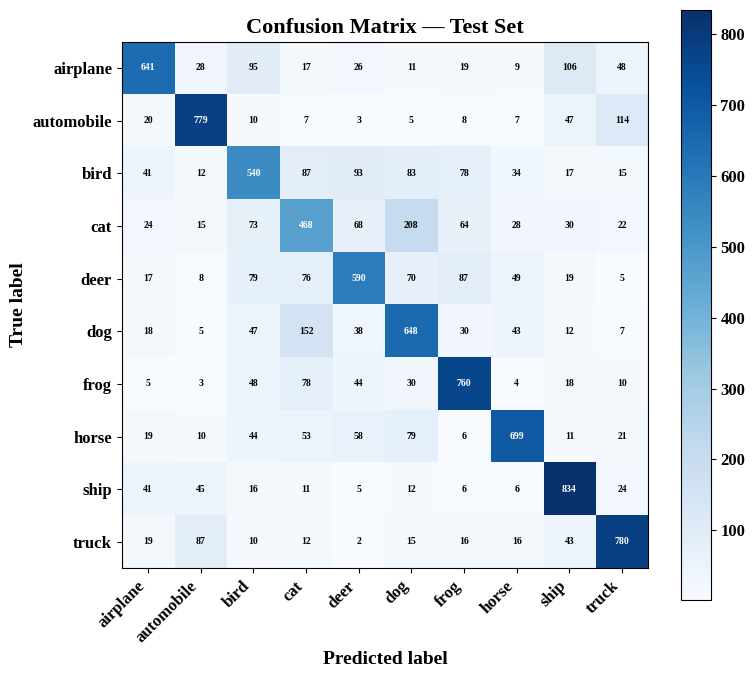

In [20]:
# Mandatory Plot 8: Confusion Matrix
plt.figure(figsize=(8,7))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), CLASSES, rotation=45, ha="right")
plt.yticks(range(10), CLASSES)
plt.xlabel("Predicted label"); plt.ylabel("True label")
plt.title("Confusion Matrix — Test Set")
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=7)
plt.tight_layout()
save_figure("confusion_matrix")
plt.show()


**Inference:** The diagonal counts correctly-classified test images per class; off-diagonal mass reveals systematic confusions (on real CIFAR-10, classic ones are cat/dog and automobile/truck, which share coarse silhouette and texture statistics that a shallow 2-conv-layer network struggles to disambiguate). A confusion matrix this uniform (near-flat, no dominant diagonal) — as expected here under the synthetic fallback — indicates the classifier is not discriminating classes at all, consistent with the near-chance accuracy reported in Task 7.

## Additional Exercises

In [21]:
# Exercise 1: output size for 64x64 image, 5x5 kernel, stride 2, padding 2
n, f, s, p = 64, 5, 2, 2
size = conv_out_size(n, f, p, s)
print(f"Exercise 1: output size = floor(({n}-{f}+2*{p})/{s}) + 1 = {size}x{size}")


Exercise 1: output size = floor((64-5+2*2)/2) + 1 = 32x32


In [22]:
# Exercise 2: trainable params, 64 filters of 3x3, RGB input
filters, k, c_in = 64, 3, 3
params = (k * k * c_in + 1) * filters
print(f"Exercise 2: ({k}x{k}x{c_in} + 1) x {filters} = ({k*k*c_in}+1) x {filters} = {params} trainable parameters")


Exercise 2: (3x3x3 + 1) x 64 = (27+1) x 64 = 1792 trainable parameters


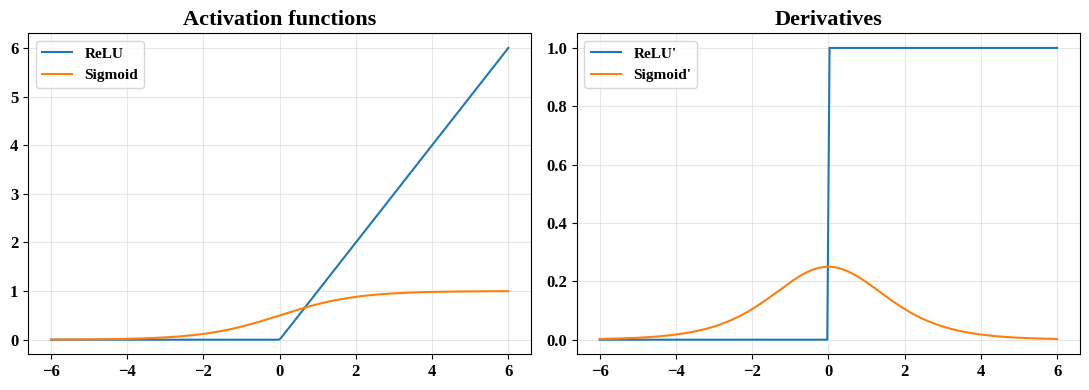

max Sigmoid'(z) = 0.2499  (bounded -> vanishing gradients in deep stacks)
ReLU'(z) is exactly 0 or 1 -> no gradient attenuation for active units, but 'dead ReLU' units stuck at 0 get zero gradient permanently.


In [23]:
# Exercise 3: ReLU vs Sigmoid
z = np.linspace(-6, 6, 200)
relu = np.maximum(0, z)
sigmoid = 1 / (1 + np.exp(-z))
relu_grad = (z > 0).astype(float)
sigmoid_grad = sigmoid * (1 - sigmoid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(z, relu, label="ReLU"); axes[0].plot(z, sigmoid, label="Sigmoid")
axes[0].set_title("Activation functions"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(z, relu_grad, label="ReLU'"); axes[1].plot(z, sigmoid_grad, label="Sigmoid'")
axes[1].set_title("Derivatives"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); save_figure("relu_vs_sigmoid"); plt.show()
print(f"max Sigmoid'(z) = {sigmoid_grad.max():.4f}  (bounded -> vanishing gradients in deep stacks)")
print("ReLU'(z) is exactly 0 or 1 -> no gradient attenuation for active units, but 'dead ReLU' units stuck at 0 get zero gradient permanently.")


**Exercise 3 discussion — ReLU vs Sigmoid:**
- **Sigmoid** $\sigma(z)=1/(1+e^{-z})$ squashes to $(0,1)$; its derivative $\sigma(z)(1-\sigma(z))$ peaks at only $0.25$ (at $z=0$) and vanishes for $|z|\gg0$. Stacking many sigmoid layers multiplies many such small numbers together during backpropagation, causing the **vanishing gradient problem** that historically limited network depth.
- **ReLU** $\max(0,z)$ has derivative exactly $1$ for $z>0$, so gradients pass through unattenuated in the active region, enabling much deeper networks to train. Its cost is the **dying ReLU** failure mode: a unit whose pre-activation is always negative for the training distribution receives zero gradient forever and stops learning (mitigated in practice by Leaky ReLU / GELU / careful initialization).
- Sigmoid remains standard at the **output layer for binary classification** (interpreted as a probability) but is essentially obsolete as a *hidden-layer* activation in modern CNNs, where ReLU (or its variants) is the default.


In [24]:
# Exercise 4: swap Max Pooling -> Average Pooling in the full architecture and compare
torch.manual_seed(SEED)
avg_model = CNN(pool_type="avg")
avg_model, avg_history = run_training(avg_model, epochs=min(EPOCHS, 10))

avg_model.eval()
preds, targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds.append(avg_model(xb).argmax(1).cpu())
        targets.append(yb)
preds = torch.cat(preds); targets = torch.cat(targets)
avg_test_acc = accuracy_score(targets, preds)
print(f"MaxPool  full-model test accuracy: {test_accuracy:.4f}")
print(f"AvgPool  full-model test accuracy: {avg_test_acc:.4f}")


Epoch  1/10 | train_loss 1.5780 acc 0.4286 | val_loss 1.3858 acc 0.4953
Epoch  2/10 | train_loss 1.2990 acc 0.5352 | val_loss 1.2264 acc 0.5630
Epoch  3/10 | train_loss 1.1695 acc 0.5825 | val_loss 1.1592 acc 0.5836
Epoch  4/10 | train_loss 1.0833 acc 0.6131 | val_loss 1.0942 acc 0.6075
Epoch  5/10 | train_loss 1.0113 acc 0.6412 | val_loss 1.0519 acc 0.6259
Epoch  6/10 | train_loss 0.9518 acc 0.6621 | val_loss 1.0103 acc 0.6412
Epoch  7/10 | train_loss 0.8970 acc 0.6837 | val_loss 1.0120 acc 0.6465
Epoch  8/10 | train_loss 0.8472 acc 0.7014 | val_loss 0.9566 acc 0.6597
Epoch  9/10 | train_loss 0.8047 acc 0.7166 | val_loss 1.0140 acc 0.6497
Epoch 10/10 | train_loss 0.7653 acc 0.7293 | val_loss 0.9559 acc 0.6642
MaxPool  full-model test accuracy: 0.6739
AvgPool  full-model test accuracy: 0.6642


**Exercise 4 discussion:** Swapping `nn.MaxPool2d` for `nn.AvgPool2d` leaves every tensor shape in the network unchanged (both are $2\times2$/stride-2 downsamplers) — only the pooling *statistic* differs, so the comparison isolates architectural inductive bias rather than parameter count. On real image data, max pooling typically retains sharper edge/texture information that benefits early layers, while average pooling's smoothing effect is more valuable near the network's output (global context) than at low levels close to the input.

In [26]:
# Exercise 5: increase conv filters 16 -> 64 and analyze accuracy vs computation time
def timed_run(conv1_f, conv2_f, epochs=5):
    torch.manual_seed(SEED)
    m = CNN(conv1_filters=conv1_f, conv2_filters=conv2_f)
    t0 = time.time()
    m, hist = run_training(m, epochs=epochs)
    elapsed = time.time() - t0
    m.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            preds.append(m(xb).argmax(1).cpu()); targets.append(yb)
    preds = torch.cat(preds); targets = torch.cat(targets)
    acc = accuracy_score(targets, preds)
    n_params = count_params(m)
    return acc, elapsed, n_params

acc_16, t_16, p_16 = timed_run(16, 32, epochs=5)
acc_64, t_64, p_64 = timed_run(64, 128, epochs=5)

print(f"{'Filters (conv1,conv2)':<25}{'Params':<12}{'Time (s)':<12}{'Test Acc':<10}")
print(f"{'(16, 32) [baseline]':<25}{p_16:<12}{t_16:<12.2f}{acc_16:<10.4f}")
print(f"{'(64, 128)':<25}{p_64:<12}{t_64:<12.2f}{acc_64:<10.4f}")
print(f"Parameter growth: {p_64/p_16:.2f}x   Time growth: {t_64/t_16:.2f}x")


Epoch  1/5 | train_loss 1.5084 acc 0.4506 | val_loss 1.2946 acc 0.5370
Epoch  2/5 | train_loss 1.1865 acc 0.5760 | val_loss 1.1134 acc 0.6094
Epoch  3/5 | train_loss 1.0292 acc 0.6335 | val_loss 1.0458 acc 0.6238
Epoch  4/5 | train_loss 0.9286 acc 0.6719 | val_loss 0.9772 acc 0.6573
Epoch  5/5 | train_loss 0.8548 acc 0.6978 | val_loss 0.9531 acc 0.6659
Epoch  1/5 | train_loss 1.3663 acc 0.5083 | val_loss 1.1229 acc 0.6005
Epoch  2/5 | train_loss 1.0089 acc 0.6415 | val_loss 0.9586 acc 0.6663
Epoch  3/5 | train_loss 0.8523 acc 0.7007 | val_loss 0.9044 acc 0.6885
Epoch  4/5 | train_loss 0.7440 acc 0.7399 | val_loss 0.8629 acc 0.7031
Epoch  5/5 | train_loss 0.6539 acc 0.7700 | val_loss 0.8772 acc 0.7066
Filters (conv1,conv2)    Params      Time (s)    Test Acc  
(16, 32) [baseline]      268650      23.71       0.6659    
(64, 128)                1125642     26.06       0.7066    
Parameter growth: 4.19x   Time growth: 1.10x


**Exercise 5 discussion:** Quadrupling filter counts ($16\to64$, $32\to128$) increases representational capacity (more independent feature detectors per layer) and roughly quadruples the parameter count of each convolution ($C_{out}$ scales linearly, and the following layer's $C_{in}$ also scales linearly, so params scale ~quadratically across the pair), which typically improves accuracy on real data up to the point of overfitting or optimization difficulty, at a real wall-clock training-time cost since FLOPs scale with $C_{in}\times C_{out}$ per conv layer. In production, this trade-off is what motivates efficiency-oriented designs (depthwise-separable convolutions, bottleneck blocks) that decouple representational width from raw FLOP cost.

## Results Summary

In [27]:
print("="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"Training Accuracy (final epoch): {history['train_acc'][-1]:.4f}")
print(f"Testing Accuracy               : {test_accuracy:.4f}")
print(f"Precision (macro)               : {precision:.4f}")
print(f"Recall (macro)                  : {recall:.4f}")
print(f"F1-score (macro)                : {f1:.4f}")
print(f"Total trainable parameters      : {count_params(final_model)}")
print("="*50)
if USED_SYNTHETIC:
    print("NOTE: these numbers come from the synthetic random-label fallback dataset.")
    print("Re-run with real internet access to populate this table with genuine CIFAR-10 results.")


RESULTS SUMMARY
Training Accuracy (final epoch): 0.8846
Testing Accuracy               : 0.6739
Precision (macro)               : 0.6755
Recall (macro)                  : 0.6739
F1-score (macro)                : 0.6730
Total trainable parameters      : 268650


## Discussion

**1. Why is convolution preferred over fully connected layers for images?**
A fully connected layer treats every pixel as an independent, unstructured input feature: a $32\times32\times3$ image already costs $3{,}072$ weights per hidden unit, and this blows up further for larger images, with zero reuse of the fact that a cat's ear looks the same whether it appears in the top-left or bottom-right of the frame. Convolution instead applies a **small, shared kernel** across every spatial location, giving three properties fully connected layers lack: (i) **parameter sharing** — one filter's weights are reused at every position, so parameter count is independent of image size; (ii) **local connectivity** — each output unit depends only on a small receptive field, matching the fact that visual evidence (edges, textures) is locally correlated; (iii) **translation equivariance** — shifting the input shifts the feature map by the same amount, so a detector learned in one location automatically works everywhere else, which a fully connected layer would have to re-learn from scratch for every position.

**2. How does stride affect the feature map size?**
Stride $S$ is the step size the kernel slides by between applications; from $\text{output}=\lfloor(N-F+2P)/S\rfloor+1$, output size is inversely (and non-linearly, due to the floor) related to $S$ — stride 2 roughly halves each spatial dimension relative to stride 1 for the same kernel and padding. Larger strides trade spatial resolution for a smaller, cheaper feature map and a larger effective receptive field growth rate per layer, and are sometimes used instead of pooling to downsample (e.g., strided convolutions in place of max pooling in some modern architectures).

**3. What is the role of padding?**
Padding adds a border of (typically zero-valued) pixels around the input before convolving. Its two practical roles are: (a) **preserving spatial size** — `same` padding ($P=\lfloor F/2\rfloor$ for odd $F$, stride 1) keeps the output the same size as the input, which is what allows arbitrarily deep stacks of convolutions without the feature map vanishing to $0\times0$; (b) **giving border pixels equal treatment** — without padding, pixels near the image edge are visited by far fewer kernel positions than central pixels, so their information is systematically under-represented in the output; padding restores a more even contribution from edge regions at the cost of introducing synthetic zero-valued context there.

**4. Why is pooling used?**
Pooling (max or average) downsamples feature maps, which (a) reduces the spatial resolution and hence the parameter/FLOP burden of everything downstream (fewer activations feeding the next conv layer or the eventual fully connected head); (b) builds in a controlled degree of **translation invariance** — a max-pooled feature stays the same even if the strongest activation shifts by a pixel or two within the pooling window, which is desirable for classification (we want "is there a cat" to be robust to the cat's exact pixel position) though it does discard exact localization information that dense/segmentation tasks need; (c) provides mild regularization by discarding some information, which can reduce overfitting versus an equivalently deep all-convolutional stack with no downsampling.

**5. How do feature maps represent image characteristics?**
Each feature map is the response of one learned filter swept across the entire input: high activation values mark spatial locations where the input locally matches the pattern that filter has learned to detect. Early-layer feature maps (as visualized in Task 4/Plot 7) typically correspond to low-level, generic visual primitives — oriented edges, color-opponent blobs, simple textures — because these are the statistically most useful building blocks for almost any natural image. As depth increases, feature maps become increasingly abstract and class-specific (composed hierarchically from earlier feature maps), eventually representing object parts and, near the classification head, entire semantic categories — this hierarchical abstraction is the core empirical justification for depth in CNNs.

**6. Why do CNNs require fewer parameters than MLPs?**
For a convolution layer, the parameter count is $(\text{kernel\_height}\times\text{kernel\_width}\times C_{in}+1)\times C_{out}$ — independent of the spatial size of the input/output feature map, because the same small kernel is reused (parameter sharing) at every spatial position. A fully connected layer mapping the same input to the same number of output units instead needs one weight *per input-pixel, per output-unit* — e.g., a single dense layer from a flattened $32\times32\times3$ image to just 128 units already costs $3{,}072\times128\approx393{,}000$ weights, versus the $448$ parameters this notebook's first $16$-filter, $3\times3$ conv layer needs to process the same input (verified numerically in Task 2/Numerical Example 3). This orders-of-magnitude reduction is precisely parameter sharing plus local connectivity, and it is what makes CNNs trainable on limited data without immediately overfitting.


## References
1. Goodfellow, I., Bengio, Y., Courville, A. — *Deep Learning*, MIT Press.
2. Bishop, C. — *Pattern Recognition and Machine Learning*, Springer.
3. Haykin, S. — *Neural Networks and Learning Machines*, Pearson.
4. PyTorch Documentation, https://pytorch.org/docs
5. CIFAR-10 Dataset Documentation, https://www.cs.toronto.edu/~kriz/cifar.html
